# Yulu Bike Sharing - EDA & Hypothesis Testing

***

## 1. Problem Statement
> **About Yulu:** <br>
> Yulu is India's leading micro-mobility service provider, offering electric bikes for daily urban commutes. Their mission is to reduce traffic congestion by providing a safe, affordable, and eco-friendly transportation alternative.

> **Business Problem:** <br>
> Yulu has observed a dip in revenue and wants to understand which factors significantly influence *<u>the demand for shared electric bikes</u>* in the Indian market. Identifying these factors will allow the company to better align supply with demand and make data-driven operational decisions.

> **Objectives:**
>
> 1. Explore the dataset to understand the distribution of demand across different conditions. 
> 2. Identify variables that significantly affect the number of bikes rented.
> 3. Use statistical hypothesis testing to confirm or reject assumptions about demand drivers. 
> 4. Provide actionable business recommendations.

> **Research Questions:**
>
> 1. Does working day vs. non-working day status affect rental demand? 
> 2. Does weather condition affect rental demand? 
> 3. Does season affect rental demand? 
> 4. Does the relationship between weather and season indicate statistical dependence that could affect demand modeling?

>**Significance Level:** <br>
$\alpha$ = 0.05, pre-registered before running any test to avoid *<u>p-hacking</u>* (*data dredging*). This means a <i><u>p-value</u></i> is required to be below 0.05 to reject any null hypothesis.
> * **Note on multiple comparisons:** Running 4 hypothesis tests under $\alpha$ = 0.05 means the family-wise error rate (probability of at least one false positive) is $1 - (0.95)^4 \approx 18.5%$. This is addressed explicitly in each post-hoc analysis using Bonferroni correction.


***

## 2. Dataset Description
> **Source:** Yulu Bike Sharing Dataset - [Kaggle](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data)

> **Format:** 1 CSV file; 10,886 rows x 12 columns


| <b>Column</b> | <b>Type</b> | <b>Description</b> |
| :---: | :---: | :---: |
| `datetime` | datetime | Hourly timestamp |
| `season` | categorical (1-4) | <b>1:</b> Spring, <b>2:</b> Summer, <br> <b>3:</b> Fall, <b>4:</b> Winter |
| `holiday` | binary | <b>1:</b> public holiday, <b>0:</b> not a holiday |
| `workingday` | binary | <b>1:</b> working day, <b>0:</b> weekend/holiday |
| `weather` | categorical (1-4) | <b>1:</b> Clear/Partly cloudy, <b>2:</b> Mist/Cloudy, <br> <b>3:</b> Light Snow/Rain, <b>4:</b> Heavy Rain/Thunderstorm |
| `temp` | continuous | Temperature in Celsius |
| `atemp` |  continuous | Feels like temperature in Celsius |
| `humidity` |  continuous | Relative humidity (%) |
| `windspeed` |  continuous | Wind speed |
| `casual` |  count | Count of casual (non-registered) users |
| `registered` |  count | Count of registered users |
| `count` |  <b>target</b> | *<u>Target variable</u>* - total rental count (casual + registered) | 


<div style="clear: both;"></div>

> **Prior expectations before seeing the data:**
>
> *  `weather` and `season` are expected to be the strongest drivers - extreme conditions intuitively suppress outdoor activity;
> *  `workingday` is expected to affect demand - casual and registered users may offset each other;
> *  `temp` is expected to correlate positively with demand and `humidity` - negatively, as more comfortable weather conditions encourage outdoor mobility.

In [1]:
%%html
<style>
table{float:left}
</style>


***

## 3. Imports and Setup

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import shapiro
from statsmodels.graphics.gofplots import qqplot
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

ALPHA = 0.05


***

## 4. Load and Inspect Data
First inspectation: shape, null values, diplicates, data types. This step determines whether the dataset is ready for analysis or needs structural fixes before proceeding.

In [3]:
df = pd.read_csv('yulu_bike_sharing_dataset.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1/1/2011 0:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,1/1/2011 1:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,1/1/2011 2:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,1/1/2011 3:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,1/1/2011 4:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
print(f'Shape: {df.shape}') # Number of rows and columns
print(f'\nNull values: \n{df.isna().sum()}') 
print(f'\nDuplicates: {df.duplicated().sum()}') 

Shape: (10886, 12)

Null values: 
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Duplicates: 0


In [5]:
df.info() # Description of the data (data type)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
df.describe().T # Description of the data (continuous data description)

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


>**Initial observations:**
> * 10,886 rows; 12 columns - no null values, no duplicates. Dataset is structurally clean;
> * Target variable `count` ranges from 1 to 977, mean $\approx$ 191. Strong right skew anticipated;
> * `casual` + `registered` = `count` exactly - no data leakage since as target is used only `count`;
> * `season` and `weather` are stored as integers but are inherently categorical - must be casted before any group-level analysis.


***

## 5. Data Preprocessing
>**Why this step matters for subsequent analysis?** <br>
>Raw integer codes for `season` (1-4) and `weather` (1-4) carry implicit ordinal meaning that could mislead statistical tests and visualizations. They need to be converted to labeled categories so that group comparisons are semantically correct. Temporal features are also extracted from `datetime` because time-of-day and month are expected demand drivers that would otherwise be buried in a single timestamp column. 

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.dayofweek

# Casting categoricals so seaborn/scipy does not treat them as numeric
cat_cols = ['season', 'holiday', 'workingday', 'weather']
for col in cat_cols:
    df[col] = df[col].astype('category')

# Makes plots and print statements easier to be read
df['season'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
df['holiday'] = df['holiday'].map({0: 'No', 1: 'Yes'})
df['workingday'] = df['workingday'].map({0: 'No', 1: 'Yes'})
df['month'] = df['month'].map({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
                               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour,day
0,2011-01-01 00:00:00,Spring,No,No,1,9.84,14.395,81,0.0,3,13,16,2011,Jan,0,5
1,2011-01-01 01:00:00,Spring,No,No,1,9.02,13.635,80,0.0,8,32,40,2011,Jan,1,5
2,2011-01-01 02:00:00,Spring,No,No,1,9.02,13.635,80,0.0,5,27,32,2011,Jan,2,5
3,2011-01-01 03:00:00,Spring,No,No,1,9.84,14.395,75,0.0,3,10,13,2011,Jan,3,5
4,2011-01-01 04:00:00,Spring,No,No,1,9.84,14.395,75,0.0,0,1,1,2011,Jan,4,5



***

## 6. Outlier Detection and Treatment
>**Interquartile Range method:**
>IQR method is used to flag outliers. A value is an outlier if it lies below $Q1 - 1.5 * IQR$ or above $Q3 + 1.5 * IQR$.

>**Winsorization (capping):**
>is applied as the treatment (what to be done with the outliers once found) rather than row removal for two reasons: <br>
> 1. The dataset is relatively small and dropping outlier rows would reduce statistical power;
> 2. Extreme rental counts are rare but real events. Capping preserves the observation while limiting distortion of distributional statistics.

>**Columns checked:**
>`windspeed`, `casual`, `registered`, `count`. The variables `temperature` and `humidity` are bounded by nature and do not require treatment.

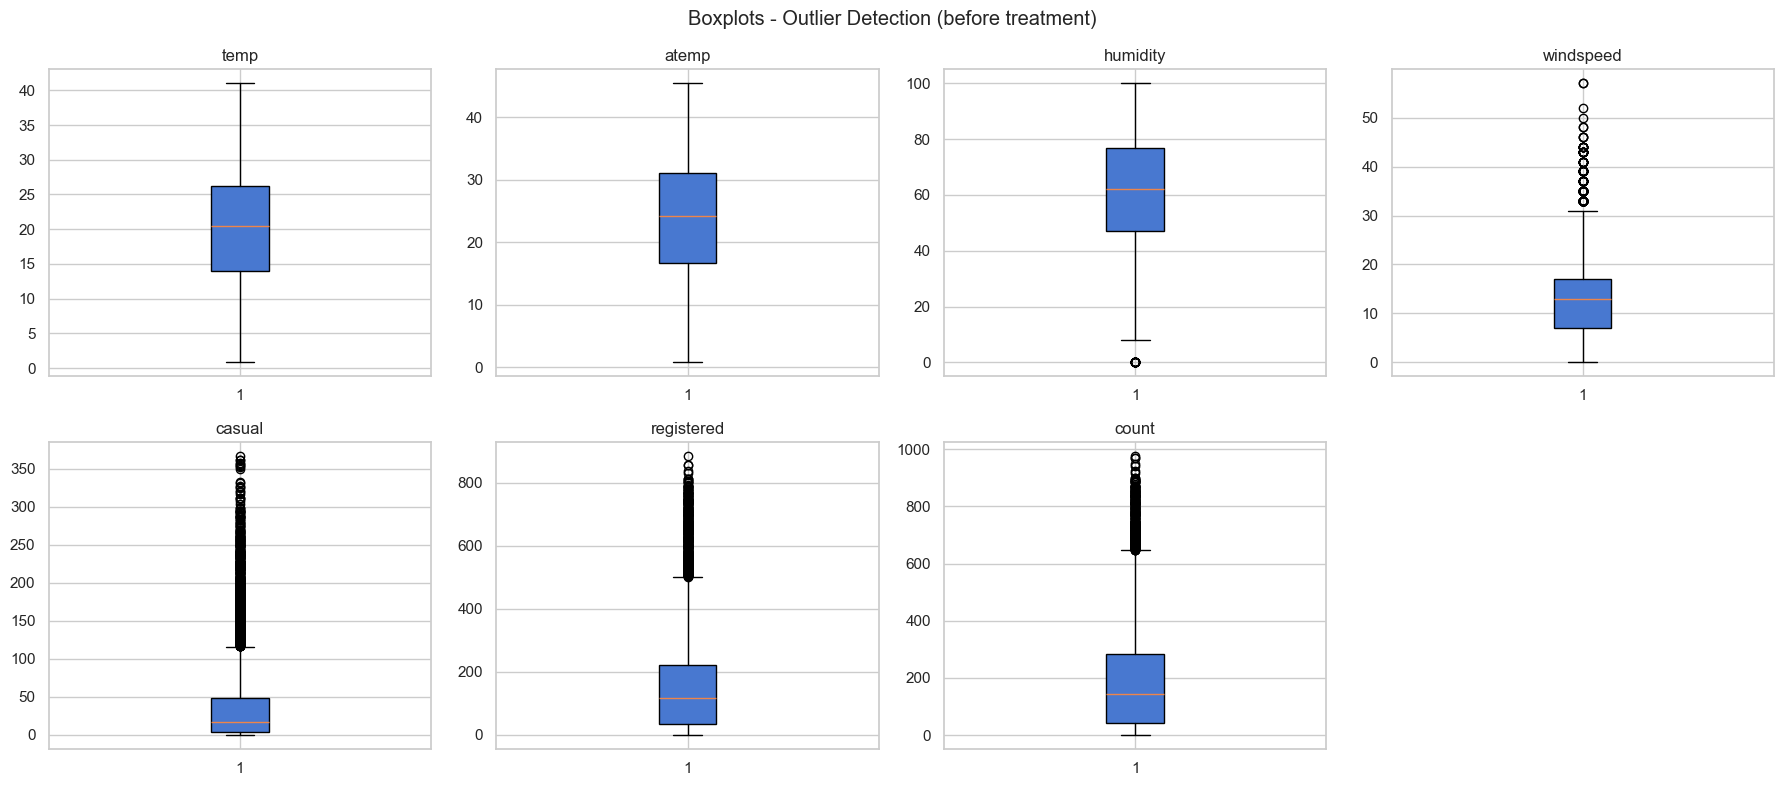

In [8]:
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten() # Converting 2D array of axes into a flat list for easier interpretation

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True)
    axes[i].set_title(col)

axes[-1].set_visible(False)

plt.suptitle('Boxplots - Outlier Detection (before treatment)')
plt.tight_layout()
plt.show()

Each box shows the interquartile range (Q1-Q3), with the horizontal line inside being the median. Individual points plotted beyond the whiskers are outliers by the IQR definition. <br>
The boxplots confirm that:
* `windspeed`, `casual`, `registered`, and `count` all have visible outliers - shown as dots above the upper ends;
* `temp`, `atemp`, and `humidity` show no extreme outliers, which is expected since these are physically bounded measurements.

In [9]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print('IQR Outlier Bounds and Counts: ')
print(f"{'Column': <14} {'Lower': >10} {'Upper': >10} {'Outliers': >10} {'% of data': >12}") # '<14' means left-align field, 14 chars wide
print(' ' + '-' * 60)

for col in ['windspeed', 'casual', 'registered', 'count']:
    lower_bound, upper_bound = iqr_bounds(df[col])
    num_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum() # Boolean mask which counts values outside both fences
    print(f' {col: <14} {lower_bound: >10.2f} {upper_bound: >10.2f} {num_outliers: >10d} {num_outliers/len(df)*100: >11.1f}%')

IQR Outlier Bounds and Counts: 
Column              Lower      Upper   Outliers    % of data
 ------------------------------------------------------------
 windspeed           -7.99      31.99        227         2.1%
 casual             -63.50     116.50        749         6.9%
 registered        -243.00     501.00        423         3.9%
 count             -321.00     647.00        300         2.8%


* `casual` has the highest outlier rate at roughly 7% of observations, reflecting occasional spikes from events or holidays;
* `registered` has 3.9% outliers and `count` - 2.8%, both moderate, suggesting high-demand hours exist but are not frequent enough to dominate the dataset;
* `windspeed` has the fewest outliers at 2.1%, which are likely genuine high-wind events rather than data errors.

All 4 columns show only upper-tail outliers - there are no abnormally low values, which makes physical sense since rentals and wind speed cannot be negative.

In [10]:
df_clean = df.copy()

for col in ['windspeed', 'casual', 'registered', 'count']:
    lower_bound, upper_bound = iqr_bounds(df[col])
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound) # The clip function replaces any value that exceeds a bound with the bound value itself

print('Distribution comparison before vs. after Winsorization:\n')
print(f" {'Metric': <22} {'Before': >10} {'After': >10}")
print(' ' + '-' * 60)

stats_to_compare = [
    ('count mean', lambda s: s.mean()),
    ('count std', lambda s: s.std()),
    ('count median', lambda s: s.median()),
    ('count max', lambda s: s.max()),
]

for stat_name, func in stats_to_compare:
    print(f" {stat_name: <22} {func(df['count']): >10.2f} {func(df_clean['count']): >10.2f}")

print(f'\n Rows before: {len(df)} | Rows after: {len(df_clean)} (no rows dropped)')

Distribution comparison before vs. after Winsorization:

 Metric                     Before      After
 ------------------------------------------------------------
 count mean                 191.57     188.70
 count std                  181.14     172.42
 count median               145.00     145.00
 count max                  977.00     647.00

 Rows before: 10886 | Rows after: 10886 (no rows dropped)


Mean and median are almost unchanged after capping - confirming that the outliers were sparse extreme values, not a systematic data quality issue. The standard deviation decreases slightly, which is expected after capping the right tail.
* If rows were removed instead of capping, genuine high-demand observations would have been lost (such as popular holidays), which are arguably the most interesting data points for Yulu's operational planning.


***

## 7. Exploration Data Analysis (EDA)
> **Why EDA?** - EDA serves two purposes here: <br>
> 1. *Understand the data* - distributions, central tendencies, variance across groups;
> 2. *Inform test selection* - specifically, whether the target variable (`count`) follows a normal distribution, which determines whether parametric or non-parametric hypothesis tests are used. 

EDA is presented before hypothesis testing, not after, so that test selection is evidence-based rather than post-hoc rationalized.

### 7.1. Distribution of the Target Variable (`count`)

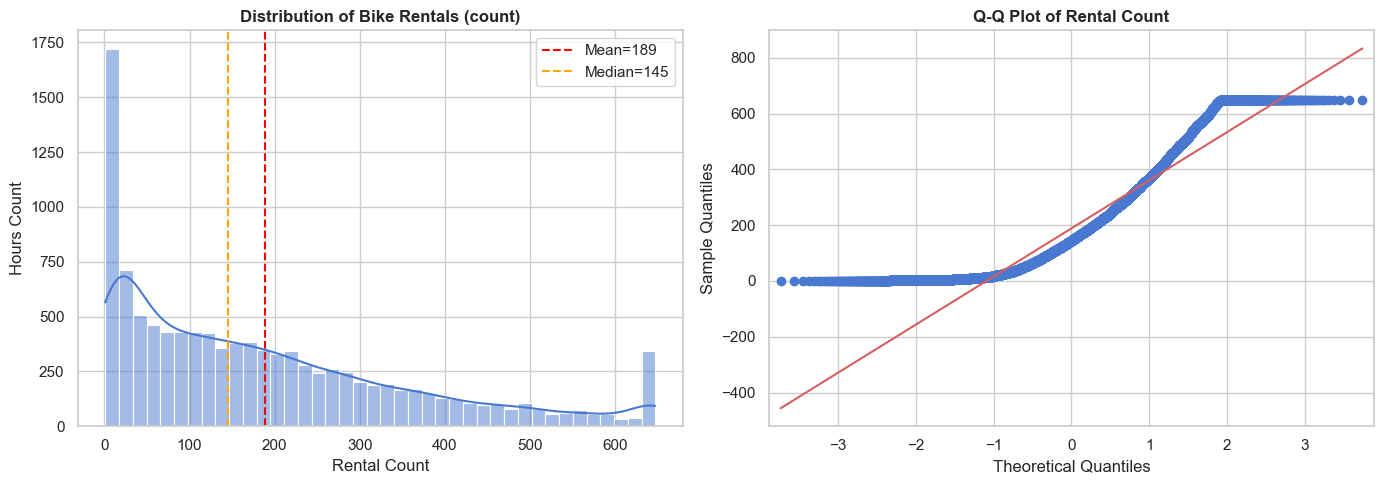

Shapiro-Wilk (n=1000 sample): stat=0.8869, p=2.1069e-26

p < α: reject normality assumption.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['count'], bins=40, kde=True, ax=ax1)
ax1.set_title('Distribution of Bike Rentals (count)', fontweight='bold')
ax1.set_xlabel('Rental Count')
ax1.set_ylabel('Hours Count')

# If mean > median the distribution is right-skewed
ax1.axvline(df_clean['count'].mean(), color='red', linestyle='--', label=f'Mean={df_clean['count'].mean():.0f}')
ax1.axvline(df_clean['count'].median(), color='orange', linestyle='--', label=f'Median={df_clean['count'].median():.0f}')
ax1.legend()

qqplot(df_clean['count'], line='s', ax=ax2) # line='s' fits a red reference line through the 25th and 75th percentiles of the data
ax2.set_title('Q-Q Plot of Rental Count', fontweight='bold')

plt.tight_layout()
plt.show()

stat, p = shapiro(df_clean['count'].sample(1000, random_state=42))
print(f'Shapiro-Wilk (n=1000 sample): stat={stat:.4f}, p={p:.4e}')
print()

if p < ALPHA:
    print('p < α: reject normality assumption.')
else:
    print('p >= α: fail to reject normality. Parametric tests may be appropriate.')

* **Histogram:** The histogram shows a right-skewed distribution - the majority of hourly observations cluster at low-to-moderate rental counts, with a long right tail representing rare high-demand hours.
* **Q-Q plot:** The Q-Q plot confirms the departure from normality: the points curve away from the reference line at both tails.
* **Normality Test:** The *Shapiro-Wilk* test formally confirms this (p < 0.05). This means parametric tests (t-test, ANOVA) that assume normality are not valid here, so non-parametric alternatives will be used throughout the hypothesis testing.
  
> **Note:** <br>
> *Shapiro-Wilk* is applied on a random subsample of 1000 observations. Because at very large `n`, the test detects trivially small deviations from normality that are statistically significant but practically irrelevant - subsampling keeps the test meaningful.

### 7.2 Categorical Variable Distributions

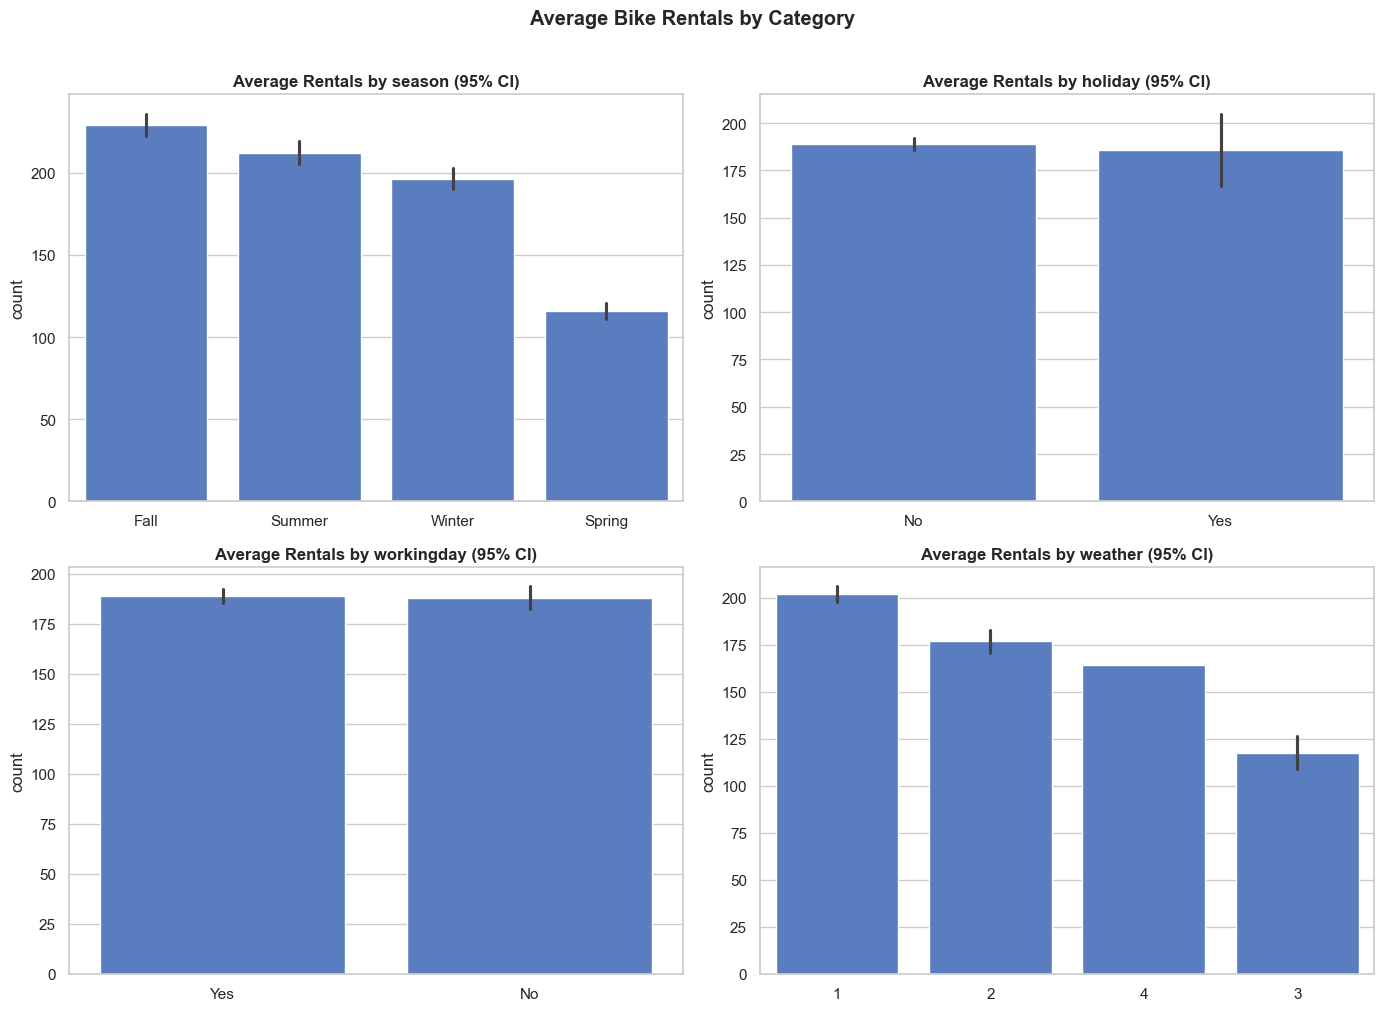

In [12]:
cat_plot_cols = ['season', 'holiday', 'workingday', 'weather']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    order = df_clean.groupby(col, observed=True)['count'].mean().sort_values(ascending=False).index
    sns.barplot(data=df_clean, x=col, y='count', order=order, ax=axes[i], errorbar=('ci', 95)) # The error bar shows 95% confidence interval around the mean
    axes[i].set_title(f'Average Rentals by {col} (95% CI)', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Average Bike Rentals by Category', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

* **Season barchart:** Fall produces the highest average rentals, followed by Summer and Winter, while Spring shows substantially lower demand - roughly half of Fall's average rentals; 
* **Holiday barchart:** Holiday vs. Non-holiday days show nearly identical average rentals. The large overlap in confidence intervals (CI) suggests that holiday status alone is not a strong driver of demand;
* **Workingday barchart:** Working days vs. Non-working days also show minimal difference in average rentals, with almost identical bar heights and strongly overlapping CI. Though visually similar, this factor will be formally tested in Section 8, where the full distribution, not just the mean, is taken into account; 
* **Weather barchart:** Weather shows a clear negative effect on rentals: clear conditions (category 1) have the highest rentals, followed by mist/cloudy conditions (category 2). Rentals drop further during heavy rain (category 4) and light rain/snow conditions (category 3). The chart shows category 4 before category 3 because the bars are ordered by mean rental value, however, category 4 contains very few observations, making its average statistically unstable. 
> **Note:** Weather category 4 has extremely few observations. With such a small sample size, *seaborn* cannot reliably estimate the bootstrap *CI*, so the error bar is not displayed. 

### 7.3 Temporal Patterns

Understanding hourly and monthly patterns is critical for operational planning because it informs Yulu *when* to have bikes available, not just *how many*.

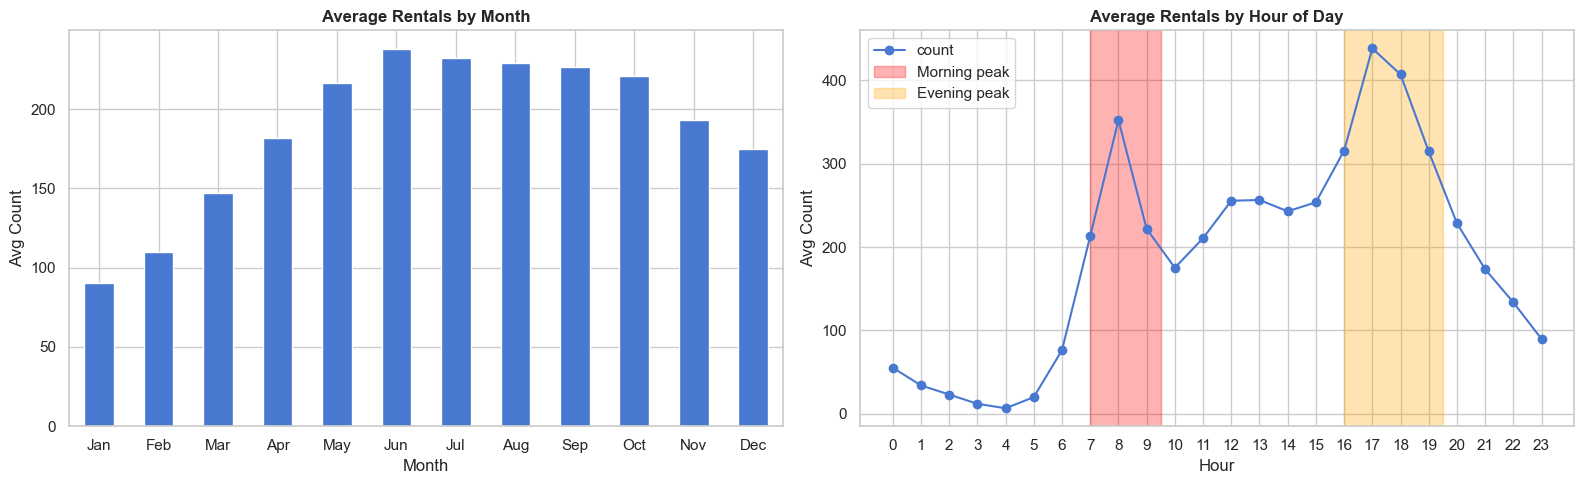

Peak hours (top 5 by average rentals):
hour
17    438.500000
18    407.289474
8     352.472527
16    315.800439
19    314.756579


In [13]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly = df_clean.groupby('month')['count'].mean().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Rentals by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Count')
axes[0].tick_params(axis='x', rotation=360)

hourly = df_clean.groupby('hour')['count'].mean()
hourly.plot(kind='line', ax=axes[1], marker='o')
axes[1].set_xticks(range(0, 24))
axes[1].set_title('Average Rentals by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Count')
axes[1].axvspan(7, 9.5, alpha=0.3, color='red', label='Morning peak') # This puts a light red shade over morning commute hours
axes[1].axvspan(16, 19.5, alpha=0.3, color='orange', label='Evening peak') # This puts a light orange shade over evening commute hours
axes[1].legend()

plt.tight_layout()
plt.show()

print('Peak hours (top 5 by average rentals):')
print(hourly.nlargest(5).to_string())

* **Month plot:** Monthly rentals peak between May and October, aligning with warmer temperatures. With June being the highest and January and February - the lowest;
* **Hour plot:** The hourly pattern shows two clear spikes: 8am and 17:00-18:00, which are classic commuter peaks. This strongly suggests registered users are primarily using Yulu for work commutes rather than leisure.

### 7.4 Casual vs. Registered Users

Analyzing rentals by user type helps identify distinct behavioral patterns between casual and registered riders, which can inform targeted operational strategies and demand management.

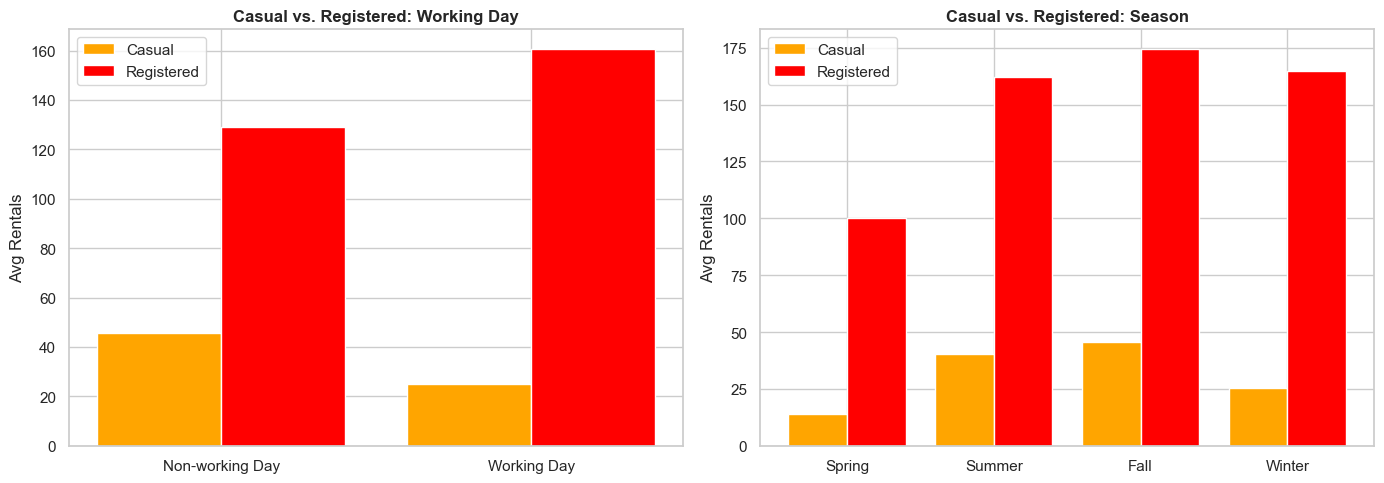

Key observations (working day):
  - Casual -> non-working: 45.6 vs. working: 24.9
  - Registered -> non-working: 129.1 vs. working: 160.5


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

workingday_groups = ['No', 'Yes']
x = np.arange(len(workingday_groups)) # [0, 1] -> numeric positions for the bars on the x-axis
casual_means = [df_clean[df_clean['workingday']==g]['casual'].mean() for g in workingday_groups]
registered_means = [df_clean[df_clean['workingday']==g]['registered'].mean() for g in workingday_groups]

# 'x-2' and 'x+2' shift the 2 bars left(-0.2)/right(+0.2) so they do not overlap
axes[0].bar(x - 0.2, casual_means, 0.4, label='Casual', color='orange') # '0.4' is the bar width
axes[0].bar(x + 0.2, registered_means, 0.4, label='Registered', color='red')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Non-working Day', 'Working Day'])
axes[0].set_title('Casual vs. Registered: Working Day', fontweight='bold')
axes[0].set_ylabel('Avg Rentals')
axes[0].legend()

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
x2 = np.arange(4)
casual_2 = [df_clean[df_clean['season']==s]['casual'].mean() for s in season_order]
registered_2 = [df_clean[df_clean['season']==s]['registered'].mean() for s in season_order]

axes[1].bar(x2 - 0.2, casual_2, 0.4, label='Casual', color='orange')
axes[1].bar(x2 + 0.2, registered_2, 0.4, label='Registered', color='red')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(season_order)
axes[1].set_title('Casual vs. Registered: Season', fontweight='bold')
axes[1].set_ylabel('Avg Rentals')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Key observations (working day):')
print(f'  - Casual -> non-working: {casual_means[0]:.1f} vs. working: {casual_means[1]:.1f}')
print(f'  - Registered -> non-working: {registered_means[0]:.1f} vs. working: {registered_means[1]:.1f}')

Registered users average roughly 2-4 times more rentals than casual users across all conditions, confirming that they form the primary demand base of the bike-sharing system.
* **Working day barchart:** On working days, registered rentals increase noticeably while casual rentals drop. The opposite pattern occurs on non-working days, where casual usage rises and registered usage falls. This crossover strongly suggests that <u>two distinct use cases coexist on the platform</u>: registered users primarily rely om the service for weekday commuting, whereas casual users tend to ride for leisure;
* **Season barchart:** Seasonally, Fall records the highest rental averages for both user groups, while Spring shows the lowest demand. Rentals remain relatively strong in Summer and Winter, particularly among registered users, suggesting that regular riders continue using the service even in colder conditions. Casual usage, however, appears more sensitive to seasonal changes, increasing mainly during warmer periods.